Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[[ 1.0000002   0.47147834  0.37841666  0.03463787  0.12613118  0.0130062
   0.04778385  0.0527837   0.00462054  0.41706684]
 [ 0.47147834  1.          0.4227835   0.13912183  0.05862397  0.07963015
   0.03050066 -0.02742581 -0.04301792  0.4690255 ]
 [ 0.37841666  0.4227835   1.0000001  -0.0045753  -0.00377966  0.01140194
   0.06750687  0.03050863  0.07407939  0.26820078]
 [ 0.03463787  0.13912183 -0.0045753   1.0000001   0.04796651  0.18439603
   0.02304166  0.01997964  0.01290903  0.1164734 ]
 [ 0.12613118  0.05862397 -0.00377966  0.04796651  0.99999994 -0.05028356
  -0.02437332  0.08850345 -0.04484363 -0.0397774 ]
 [ 0.0130062   0.07963015  0.01140194  0.18439603 -0.05028356  1.0000002
   0.01591279  0.03492601  0.09542702  0.04005572]
 [ 0.04778385  0.03050066  0.06750687  0.02304166 -0.02437332  0.01591279
   0.99999994  0.45022666  0.3636883   0.01802165]
 [ 0.0527837  -0.02742581  0.03050863  0.01997964  0.08850345  0.03492601
   0.45022666  1.          0.3444572   0.02821099]
 [

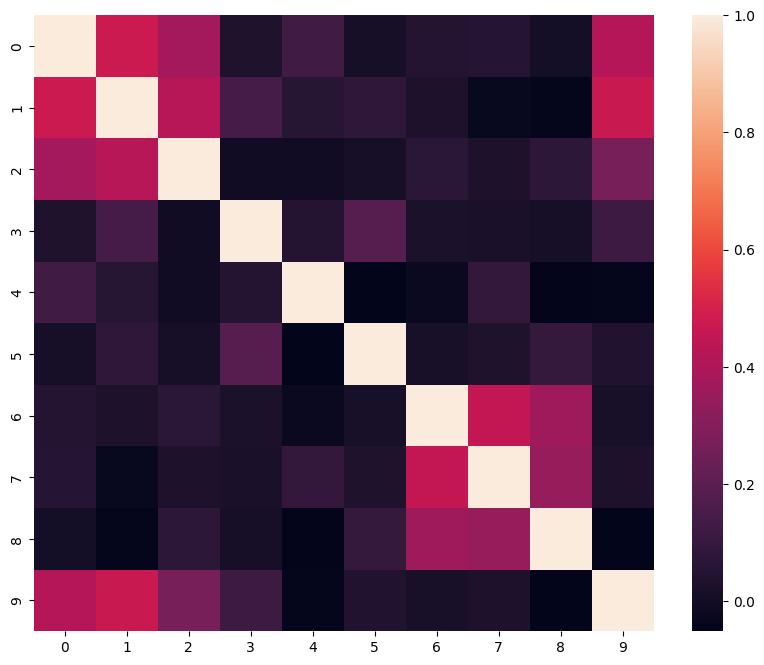

In [2]:
!pip install sentence-transformers

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sentences = [
    "Virat Kohli scored a century in the match",
    "The bowler took a wicket in the final over",
    "Cricket is a popular sport in India",
    "I cooked a delicious pasta for dinner",
    "Baking cakes requires precise measurements",
    "Spices add flavor to food",
    "Cybersecurity protects systems from attacks",
    "Hackers use phishing to steal data",
    "Strong passwords improve security",
    "The team celebrated their victory after the match"
]

model = SentenceTransformer('all-MiniLM-L6-v2')
embeddings = model.encode(sentences)

similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

df = pd.DataFrame(similarity_matrix)

plt.figure(figsize=(10,8))
sns.heatmap(df)
plt.show()

In [3]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

similarities = cosine_similarity(query_embedding, embeddings)[0]

top_indices = similarities.argsort()[-2:][::-1]

print("Top 2 similar sentences:\n")
for idx in top_indices:
    print(sentences[idx], "→ Score:", similarities[idx])

Top 2 similar sentences:

The bowler took a wicket in the final over → Score: 0.83883524
Virat Kohli scored a century in the match → Score: 0.46225673
